# OASIS INFOBYTE - DATA ANALYTICS INTERNSHIP
## Task 2 - Exploratory Data Analysis (EDA)
### Intern: Dineo Ndlovu
### Track: Data Analytics
### Dataset: SuperStore Sales Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../SuperStoreOrders_Cleaned.csv', encoding='latin1')
df.head()

,Ã¯Â»Â¿order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,Emea,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [3]:
print("=== DESCRIPTIVE STATISTICS ===")
print(df.describe())

=== DESCRIPTIVE STATISTICS ===
           quantity      discount        profit  shipping_cost          year
count  51290.000000  51290.000000  51290.000000   51290.000000  51290.000000
mean       3.476545      0.142908     28.641740      26.375915   2012.777208
std        2.278766      0.212280    174.424113      57.296804      1.098931
min        1.000000      0.000000  -6599.978000       0.000000   2011.000000
25%        2.000000      0.000000      0.000000       2.610000   2012.000000
50%        3.000000      0.000000      9.240000       7.790000   2013.000000
75%        5.000000      0.200000     36.810000      24.450000   2014.000000
max       14.000000      0.850000   8399.976000     933.570000   2014.000000


TypeError: no numeric data to plot

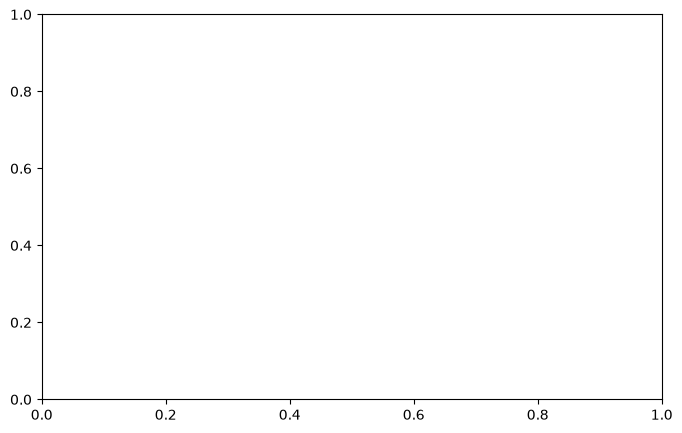

In [4]:
plt.figure(figsize=(8,5))
df.groupby('category')['sales'].sum().sort_values().plot(kind='bar', color='steelblue')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
df.groupby('region')['sales'].sum().sort_values().plot(kind='bar', color='coral')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'])
df['month_year'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month_year')['sales'].sum()

plt.figure(figsize=(14,5))
monthly_sales.plot(kind='line', color='green')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
top_products = df.groupby('product_name')['sales'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_products.plot(kind='barh', color='purple')
plt.title('Top 10 Best Selling Products')
plt.xlabel('Total Sales')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7,5))
df.groupby('segment')['sales'].sum().plot(kind='pie', autopct='%1.1f%%')
plt.title('Sales by Customer Segment')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,6))
numeric_df = df[['sales', 'quantity', 'discount', 'profit']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))
df.groupby('category')['profit'].sum().sort_values().plot(kind='bar', color='orange')
plt.title('Total Profit by Category')
plt.xlabel('Category')
plt.ylabel('Total Profit')
plt.tight_layout()
plt.show()

In [ ]:
print("=== BUSINESS INSIGHTS ===")
print("\n1. Top performing category by sales:")
print(df.groupby('category')['sales'].sum().idxmax())

print("\n2. Top performing region by sales:")
print(df.groupby('region')['sales'].sum().idxmax())

print("\n3. Most profitable category:")
print(df.groupby('category')['profit'].sum().idxmax())

print("\n4. Least profitable category:")
print(df.groupby('category')['profit'].sum().idxmin())

print("\n5. Total revenue:")
print("$", round(df['sales'].sum(), 2))